<a href="https://colab.research.google.com/github/rubencarm/cs301final/blob/main/CS301_Milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CS 301-002**

**Final Project**

Saahil Dhabalia,
Emilie Inzinna-Enriquez,
Ruben Carmona

# Data Preperation and Cleaning

These are the original datasets we used for this project:

Chicago socioeconomic indicators
*   https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2/about_data

List of metro stations in Chicago and location
*   https://data.cityofchicago.org/Transportation/CTA-System-Information-List-of-L-Stops/8pix-ypme

List of metro stations in Chicago and daily ridership
*   https://data.cityofchicago.org/Transportation/CTA-Ridership-L-Station-Entries-Daily-Totals/5neh-572f/about_data

We had to make some major modifications to the datasets to get them to work as intended.
For CTA Ridership Daily Total, we removed all dates not from the 2008-2012 range.
* Reason 1: The dataset was just too massive
* Reason 2: It better lines up with the Socioeconomic Factors dataset now, as that dataset is from 2008-2012

Then we used the Station ID column from the two CTA datasets to aggregate them into one set for simplicty. This new set is "Aggregated_CTA_Transit_Stations", and contains Stop ID, Average Daily Rides, and Coordinates.

Next, we had to tie the coordinates from the CTA set to the locations in the Socioeconomic Indicators set. This required us to use a Point-in-Point Spatial Join and geopandas.

All datasets used in this colab are in the github repository.


In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import scipy.stats as stats

In [243]:
# Load Datasets
cta_stations = "https://raw.githubusercontent.com/rubencarm/cs301final/refs/heads/main/Aggregated_CTA_Transit_Stations.csv"
socio_indicators = "https://raw.githubusercontent.com/rubencarm/cs301final/refs/heads/main/Socioeconomic_Indicators_In_Chicago.csv"
transit_df = pd.read_csv(cta_stations)
socio_df = pd.read_csv(socio_indicators)

# Convert transit data into a spatial Geoframe
geometry = [Point(xy) for xy in zip(transit_df['Longitude'], transit_df['Latitude'])]
transit_gdf = gpd.GeoDataFrame(transit_df, crs="EPSG:4326", geometry=geometry)

# Read the Chicago community areas geoJSON
chicago_geojson = "https://raw.githubusercontent.com/rubencarm/cs301final/refs/heads/main/chicago_community_areas.geojson"
community_areas_gdf = gpd.read_file(chicago_geojson)

# Make sure both maps use the same coordinate system
community_areas_gdf = community_areas_gdf.to_crs(transit_gdf.crs)

# Spatial Join
stations_in_neighborhoods = gpd.sjoin(transit_gdf, community_areas_gdf, how="inner", predicate="within")

# Aggregate transit data by community area
neighborhood_transit = stations_in_neighborhoods.groupby('area_numbe').agg( # The json has 'area_numbe' for some reason
    Total_Stations=('station_id', 'count'),
    Total_Avg_Daily_Rides=('avg_daily_rides', 'sum')
).reset_index()

neighborhood_transit['area_numbe'] = neighborhood_transit['area_numbe'].astype(float)

# Merge into the final dataframe
df = pd.merge(
    socio_df,
    neighborhood_transit,
    left_on='Community Area Number',
    right_on='area_numbe',
    how='left')

# Fill neighborhoods with 0 transit access with 0s instead of NaNs
df['Total_Stations'] = df['Total_Stations'].fillna(0)
df['Total_Avg_Daily_Rides'] = df['Total_Avg_Daily_Rides'].fillna(0)



In [244]:
# Check the dataframe
df = df.drop(columns=['area_numbe', 'Community Area Number'])
df

,COMMUNITY AREA NAME,PERCENT OF HOUSING CROWDED,PERCENT HOUSEHOLDS BELOW POVERTY,PERCENT AGED 16+ UNEMPLOYED,PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA,PERCENT AGED UNDER 18 OR OVER 64,PER CAPITA INCOME,HARDSHIP INDEX,Total_Stations,Total_Avg_Daily_Rides
0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0,4.0,15273.636835
1,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0,0.0,0.000000
2,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0,3.0,10484.341487
3,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0,4.0,8330.121126
4,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0,2.0,3884.023382
...,...,...,...,...,...,...,...,...,...,...
73,Mount Greenwood,1.0,3.4,8.7,4.3,36.8,34381,16.0,0.0,0.000000
74,Morgan Park,0.8,13.2,15.0,10.8,40.3,27149,30.0,0.0,0.000000
75,O'Hare,3.6,15.4,7.1,10.9,30.3,25828,24.0,2.0,12646.767062
76,Edgewater,4.1,18.2,9.2,9.7,23.8,33385,19.0,4.0,12790.613245


# 1. Exploratory Data Analysis

We noticed this later, but neighborhood 78 is "CHICAGO" which is an overall average of the city. We need to drop this neighborhood as it will negatively impact models and hypothesis testing. This means our official neighborhood count is 77, which lines up with official Chicago data.

In [245]:
# Remove CHICAGO
df.drop(77, inplace=True)
print(f"Neighborhood Count: {len(df)}")

Neighborhood Count: 77


**Feature Distributions**

Text(0.5, 1.0, 'Distribution of Unemployment Rate')

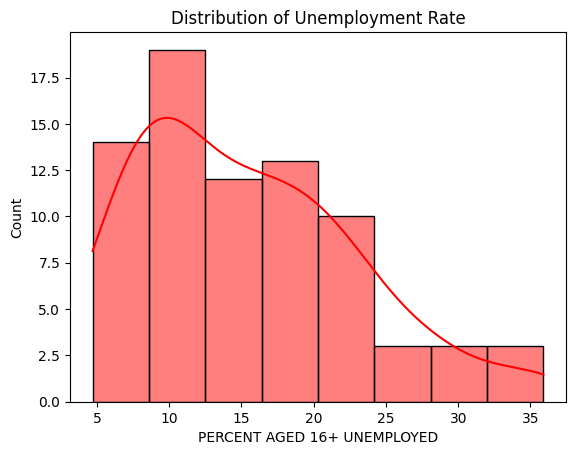

In [246]:
# Unemployment Rate is the target variable
sns.histplot(df['PERCENT AGED 16+ UNEMPLOYED'], kde=True, color='red')
plt.title('Distribution of Unemployment Rate')

We see a fair right-skew in this graph, showing that most neighborhoods have an unemplyment rate of 25% or less, with only a few neighborhoods having a higher rate.

Text(0.5, 1.0, 'Distribution of Total Stations per Neighborhood')

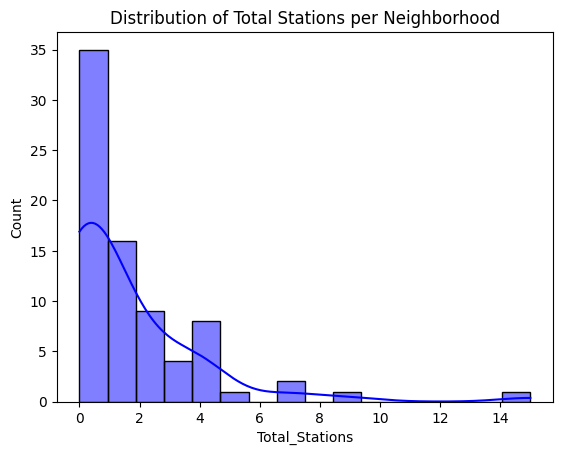

In [247]:
# Independent Variable: Transit Access
sns.histplot(df['Total_Stations'], kde=True, color='blue')
plt.title('Distribution of Total Stations per Neighborhood')

We see a heavy right-skew in this graph. Nearly half of the 77 neighborhoods do not have a train station.

Text(0.5, 1.0, 'Distribution of Total Daily Rides')

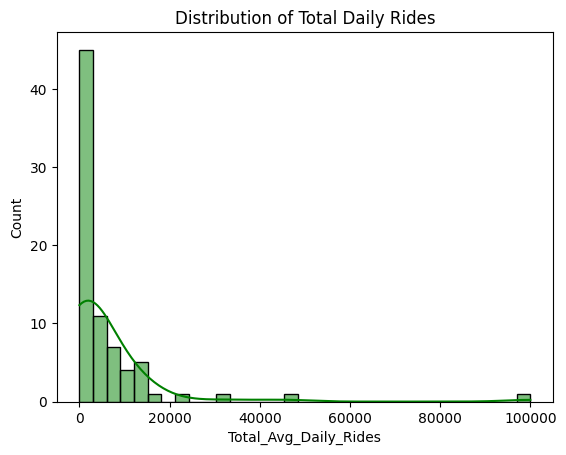

In [248]:
# Independent Variable Transit Usage
sns.histplot(df['Total_Avg_Daily_Rides'], kde=True, color='green')
plt.title('Distribution of Total Daily Rides')

We see the same skew in this graph which matches up with that of the previous graph. Because the features are heavily right-skewed this can negatively affect a linear model's performance.

**Heat Map**

Text(0.5, 1.0, 'Correlation Matrix')

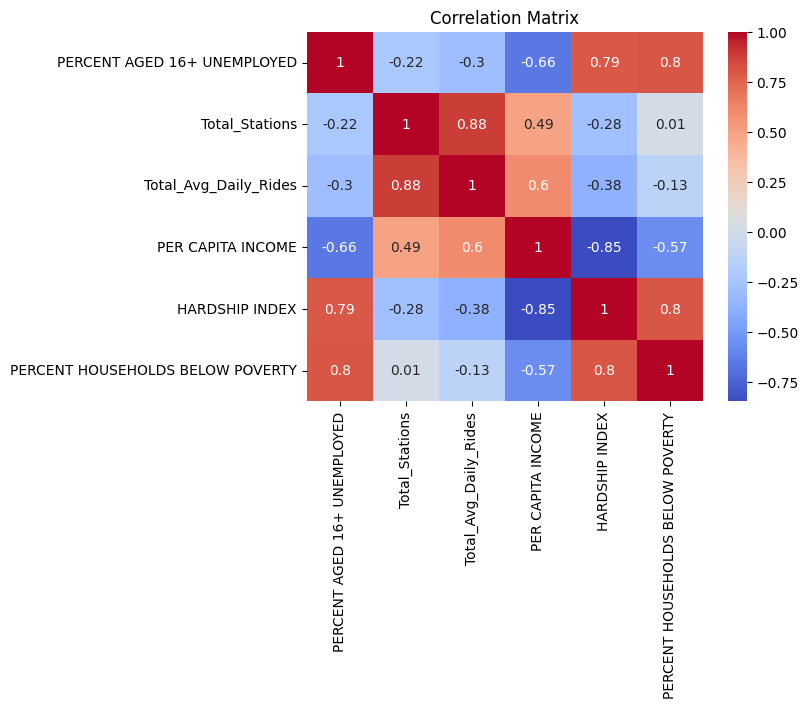

In [249]:
# Get the relevant features
important_features = ['PERCENT AGED 16+ UNEMPLOYED',
                      'Total_Stations',
                      'Total_Avg_Daily_Rides',
                      'PER CAPITA INCOME',
                      'HARDSHIP INDEX',
                      'PERCENT HOUSEHOLDS BELOW POVERTY']
# Plot the heat map
corr_matrix = df[important_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

From the heatmap we can see there is a fair to high correlation between all of these features. Between total stations and unemployment we see a -0.22 correlation, and between daily rides and unemployment there is a -0.30 correlation. However, between per capita income, we see correlations of 0.49 and 0.60 respectively, showing that access to train stations may not have as much affect on employment as it does on the type of employment.

We do see high colinearity between Hardship Index and Unemployment as well as Total Stations and Daily Rides. This makes sense as they measure similar things.

**Bitvariate Analysis**


Text(0, 0.5, 'Unemployment Rate (%)')

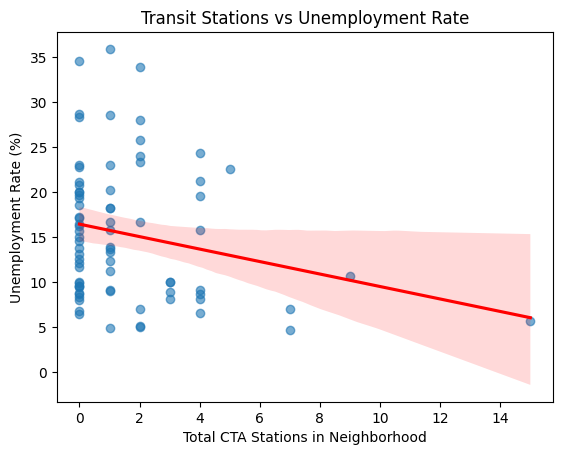

In [250]:
# Transit Access vs Unemployment
sns.regplot(data=df, x='Total_Stations', y='PERCENT AGED 16+ UNEMPLOYED',
            scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
plt.title('Transit Stations vs Unemployment Rate')
plt.xlabel('Total CTA Stations in Neighborhood')
plt.ylabel('Unemployment Rate (%)')

We see a negative correlation here between Unemployment Rate and Total Stations, however, this does seem to be heavily influenced by the outlier neighborhoods with high amounts of stations.

Text(0, 0.5, 'Unemployment Rate (%)')

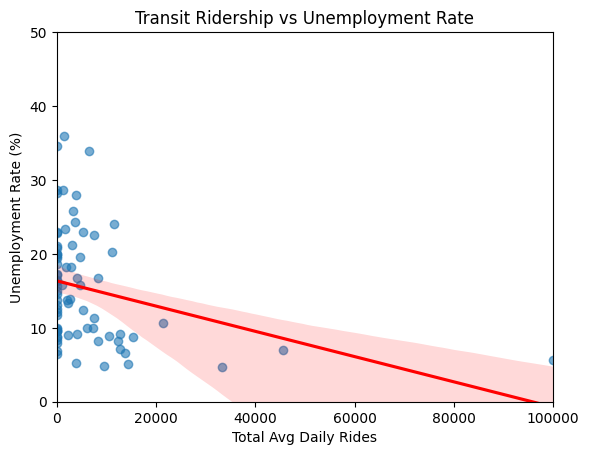

In [251]:
sns.regplot(data=df, x='Total_Avg_Daily_Rides', y='PERCENT AGED 16+ UNEMPLOYED',
            scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
plt.title('Transit Ridership vs Unemployment Rate')
plt.xlabel('Total Avg Daily Rides')
plt.axis([0, 100000, 0, 50])
plt.ylabel('Unemployment Rate (%)')

This once again follows the same behavior as the previous graph, including the affect by outliers. The majority of the data lies at the left side of the graph, and we see a fair amount of variance there. Some neighborhoods with 0 rides have <10% unemployment, where others have >30%, showing that while transit usage may be a factor, it likely isn't very important.

# 2. Hypothesis Testing

We are testing our hypotheseses:

$H_0$
: There is no significant correlation between access to public transit and local
employment rates.

$H_a$ : Neighborhoods with easier access and frequently used metro stations will have
significantly higher employment rates.




**T-Test**

In [252]:
# performing the T-Test
test_df = df.dropna(subset=['PERCENT AGED 16+ UNEMPLOYED'])

with_transit = test_df[test_df['Total_Stations'] > 0]['PERCENT AGED 16+ UNEMPLOYED']
without_transit = test_df[test_df['Total_Stations'] == 0]['PERCENT AGED 16+ UNEMPLOYED']

t_stat, t_p_value = stats.ttest_ind(with_transit, without_transit, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {t_p_value:.4e}\n")

# evaluating the p-value
if t_p_value < 0.05:
    print("Result: p < 0.05. We REJECT the Null Hypothesis (H0).")
    print("Explanation: There is a statistically significant relationship between public transit access and local unemployment rates in Chicago neighborhoods.")
else:
    print("Result: p >= 0.05. We FAIL TO REJECT the Null Hypothesis (H0).")
    print("Explanation: There is no statistically significant relationship between public transit access and local unemployment rates in Chicago neighborhoods.")

T-Statistic: -0.3244
P-Value: 7.4654e-01

Result: p >= 0.05. We FAIL TO REJECT the Null Hypothesis (H0).
Explanation: There is no statistically significant relationship between public transit access and local unemployment rates in Chicago neighborhoods.


**Chi-Squared Test**

Since the Chi-Squared test is designed for categorical data, the target variable and independent variable need to be converted.

In [253]:
# set up for the Chi-Squared test

chi_df = df.dropna(subset=['PERCENT AGED 16+ UNEMPLOYED']).copy()

# creating a categorical variable for transit access
chi_df['Transit_Category'] = chi_df['Total_Stations'].apply(
    lambda x: 'Has Transit' if x > 0 else 'No Transit'
)

# creating a categorical variable for unemployment based on the median
median_unemployment = chi_df['PERCENT AGED 16+ UNEMPLOYED'].median()
chi_df['Unemployment_Category'] = chi_df['PERCENT AGED 16+ UNEMPLOYED'].apply(
    lambda x: 'High Unemployment' if x > median_unemployment else 'Low Unemployment'
)

contingency_table = pd.crosstab(chi_df['Transit_Category'], chi_df['Unemployment_Category'])

print("Contingency Table:")
print(contingency_table)
print("-" * 60)

Contingency Table:
Unemployment_Category  High Unemployment  Low Unemployment
Transit_Category                                          
Has Transit                           19                23
No Transit                            19                16
------------------------------------------------------------


In [254]:
# performing the Chi-Squared test
chi2_stat, chi2_p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Squared Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {chi2_p_value:.4e}\n")

# evaluating the p-value
if chi2_p_value < 0.05:
    print("Result: p < 0.05. We REJECT the Null Hypothesis (H0).")
    print("Explanation: There is a statistically significant relationship between public transit access and local unemployment rates in Chicago neighborhoods.")
else:
    print("Result: p >= 0.05. We FAIL TO REJECT the Null Hypothesis (H0).")
    print("Explanation: There is no statistically significant relationship between public transit access and local unemployment rates in Chicago neighborhoods.")

Chi-Squared Statistic: 0.3156
Degrees of Freedom: 1
P-Value: 5.7424e-01

Result: p >= 0.05. We FAIL TO REJECT the Null Hypothesis (H0).
Explanation: There is no statistically significant relationship between public transit access and local unemployment rates in Chicago neighborhoods.


# 3. Model Building

Based on what we learned from the Data Analysis, we know the model is heavily right-skewed, so this can negatively affect model performance.

We chose to apply a log transformation to manipulate the data in a way where models can handle it better.

Additionally, to see how impactful these transit features are, we made two feature sets.

*   Set 1 contains only transit features. We want to see if you can accurately build a model with just transit features.
*   Set 2 contains transit features as well as more predictable features like income and poverty rates. This gives the model a lot more information as these two features will have significant correlations with unemployment rate.

We will implement two models. A linear regression model and a decision tree regressor. Linear regression will allow us to see if there's a linear relationship between these features. The decision tree regressor will allow us to see its feature importances, to see what the model decided was the most important feature to base splits on.



In [255]:
df['Log_Total_Stations'] = np.log1p(df['Total_Stations'])
df['Log_Total_Avg_Daily_Rides'] = np.log1p(df['Total_Avg_Daily_Rides'])

# Features and Target Variable
# Two sets to see just how impactful transit is
x1 = df[['Log_Total_Stations', 'Log_Total_Avg_Daily_Rides']]
x2 = df[['Log_Total_Stations', 'Log_Total_Avg_Daily_Rides', 'PER CAPITA INCOME', 'PERCENT HOUSEHOLDS BELOW POVERTY']]

y = df['PERCENT AGED 16+ UNEMPLOYED']

x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y, test_size=0.2, random_state=327)
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y, test_size=0.2, random_state=327)


# Scale the data
scaler = StandardScaler()
x_train1 = scaler.fit_transform(x_train1)
x_test1 = scaler.transform(x_test1)
x_train2 = scaler.fit_transform(x_train2)
x_test2 = scaler.transform(x_test2)

In [256]:
# Linear Model based on feature set 1
# Train the model
lin_model1 = LinearRegression()
lin_model1.fit(x_train1, y_train1)
lin_predictions1 = lin_model1.predict(x_test1)

# Evaluate Performance
lin_rmse1 = root_mean_squared_error(y_test1, lin_predictions1)
lin_r21 = r2_score(y_test1, lin_predictions1)

print("Linear Regression Model Performance:")
print(f"RMSE: {lin_rmse1:.4f}")
print(f"R2: {lin_r21:.4f}")

Linear Regression Model Performance:
RMSE: 5.8773
R2: -0.0500


In [257]:
# Linear Model based on feature set 2
# Train the model
lin_model2 = LinearRegression()
lin_model2.fit(x_train2, y_train2)
lin_predictions2 = lin_model2.predict(x_test2)

# Evaluate Performance
lin_rmse2 = root_mean_squared_error(y_test2, lin_predictions2)
lin_r22 = r2_score(y_test2, lin_predictions2)

print("Linear Regression Model Performance:")
print(f"RMSE: {lin_rmse2:.4f}")
print(f"R2: {lin_r22:.4f}")

Linear Regression Model Performance:
RMSE: 2.9677
R2: 0.7323


In [258]:
# Decision Tree Model based on feature set 1
# Train the model
dt_model1 = DecisionTreeRegressor(max_depth=5)
dt_model1.fit(x_train1, y_train1)
dt_predictions1 = dt_model1.predict(x_test1)

# Evaluate Performance
dt_rmse1 = root_mean_squared_error(y_test1, dt_predictions1)
dt_r21 = r2_score(y_test1, dt_predictions1)

print("Decision Tree Model Performance:")
print(f"RMSE: {dt_rmse1:.4f}")
print(f"R2: {dt_r21:.4f}")
print(f"Feature Importance: {dt_model1.feature_importances_}")


Decision Tree Model Performance:
RMSE: 8.8299
R2: -1.3700
Feature Importance: [0.12749016 0.87250984]


In [259]:
# Decision Tree Model based on feature set 2
# Train the model
dt_model2 = DecisionTreeRegressor(max_depth=5)
dt_model2.fit(x_train2, y_train2)
dt_predictions2 = dt_model2.predict(x_test2)

# Evaluate Performance
dt_rmse2 = root_mean_squared_error(y_test2, dt_predictions2)
dt_r22 = r2_score(y_test2, dt_predictions2)

print("Decison Tree Model Performance:")
print(f"RMSE: {dt_rmse2:.4f}")
print(f"R2: {dt_r22:.4f}")
print(f"Feature Importance: {dt_model2.feature_importances_}")

Decison Tree Model Performance:
RMSE: 2.9087
R2: 0.7428
Feature Importance: [0.02627559 0.05560308 0.14394476 0.77417656]


# 4. Knowledge Discovery

Based on the two models and the two feature sets this is what we learned:

**Feature Set 1**: Just Transit features

Both the linear and decision tree model fail to output any real useful data. With a negative r2 score in both models, it is essentially worse than random guessing. This shows that transit information alone doesn't correlate to unemployment rate in an area.


**Feature Set 2**: Transit + Poverty & Income

Both the linear and decision tree model significantly improved when we added Income and Poverty into the feature set. Based on the decision tree feature importances we can see that transit was barely considered when making decision (only about 8%), whereas income and poverty were the main deciding factors, showing that transit information isn't very useful when predicting unemployment rate.

**Conclusion**

Our hypothesis tests showed that the the common urban myth that increasing access to public transit (specifically CTA metro stations) will decrease unemployment rates. The tests had no correlation between the number of train stations and a given neighborhood's unemployment rate. The existing socioeconomic factors, such as poverty and income, better helped to make predictions instead. Based on this, our actionable insight is that the City of Chicago should not rely on access to public transit to promote job growth. Instead, the city should focus on direct economic solutions like targeted job training programs, small business grants, and improving the cheaper transit options (like buses). This would better belp the unemployment rates.

This outcome is suprising as our original instinct was that more transit would correlate to higher employment rates, but it does follow along with our hypothesis test. Something that could be important to factor would be personal transportation. Areas with higher income/employment would likely also have easier access to personal transportation, and would be unlikely to utilize public transportation as much. Areas with lower unemployment would likely be poorer, but will still need a form of transportation to get necessities like grociers, hence a $2 train ticket would be more manageable than owning a car.

It's also important to note that the decision tree regressor chose total average daily rides as a significantly more important feature than total stations in a neighborhood. These two features do have a high colinearity as they do present similar info. Maybe if we want to make predictions utilizing just transit info, we may need a more diverse data set with more information about transit, such as how old the average rail car is, safety, cleanliness, etc.

Another very important note is that this dataframe only takes metro stations into account, ignoring all information about other forms of public transportation, like busses. About 55% of Chicago commuters who utilize public transportation use the train (https://www.transitstats.co/cta-ridership-data). However public transit only accounts for about 20% of total daily commutes in chicago (https://city-stats.com/illinois/chicago/), meaning that train data only makes up 10% of all commuters in Chicago. This means we are working with a very small set of the total data and are ignoring 90% of other factors involved.

Despite that, it is still interesting to note how there is very little correlation between metro stations and employment rate in Chicago.